In [1]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(100))

541


In [12]:
add([1,2])

3

In [9]:
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(200))

1223


In [11]:
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(300))

1987


In [7]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions


def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j
    
level = 11
bound =2400
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
print("expansion[:5]:",expansion[:5])
coeffs_list=[pair[1] for pair in expansion]
h_list=[1]+coeffs_list
j_list=j_sequence_from_h(h_list)
c=1 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
deformed_j_list=[c]+j_list
print("new deformed j_list:")
print(deformed_j_list[:5])
print("old deformed j_list:")
old_deformed_j_list_pairs=[(0,1)] # first entry is just an offset. 
for n in range(1,351):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+old_deformed_j_list_pairs[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    old_deformed_j_list_pairs.append((n,j_n))
old_j_list=[pair[1] for pair in old_deformed_j_list_pairs]
print(deformed_j_list[:5])

label: 11a1
expansion[:5]: [(1, 1), (2, -2), (3, -1), (4, 2), (5, 1)]
new deformed j_list:
[1, 1, -5, 4, -5]
old deformed j_list:
[1, 1, -5, 4, -5]


curve expansion finished at minutes  0.00011775096257527669
label: 11a1
coeffs_list finished at minutes  0.00012938578923543293
h_list finished at minutes  0.00013408263524373372
j_list finished at minutes  0.009497384230295816
deformed_j_list finished at minutes  0.00950313409169515
deformed_h_list finished at minutes  0.6946390509605408
deformed_h_list[0]: 1
n: 0 elapsed: 0.6946497360865275
n: 1 elapsed: 0.6958256165186564
n: 2 elapsed: 0.6959732333819072
n: 3 elapsed: 0.6962629318237304
n: 4 elapsed: 0.6963115692138672
n: 5 elapsed: 0.696338935693105
n: 6 elapsed: 0.6963759501775105
n: 7 elapsed: 0.6964052836100261
n: 8 elapsed: 0.6964338660240174
n: 9 elapsed: 0.6964698990186056
n: 10 elapsed: 0.6965281367301941
n: 11 elapsed: 0.696594766775767
n: 12 elapsed: 0.6966646989186605
n: 13 elapsed: 0.6967441201210022
n: 14 elapsed: 0.6968712687492371
n: 15 elapsed: 0.6970126986503601
n: 16 elapsed: 0.6971813996632894
n: 17 elapsed: 0.6973398327827454
n: 18 elapsed: 0.6975162347157796
n: 

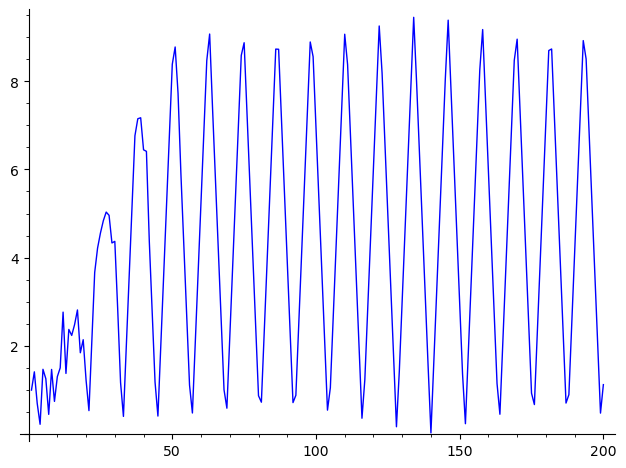

anomalies: 0 610
LOGPLOT


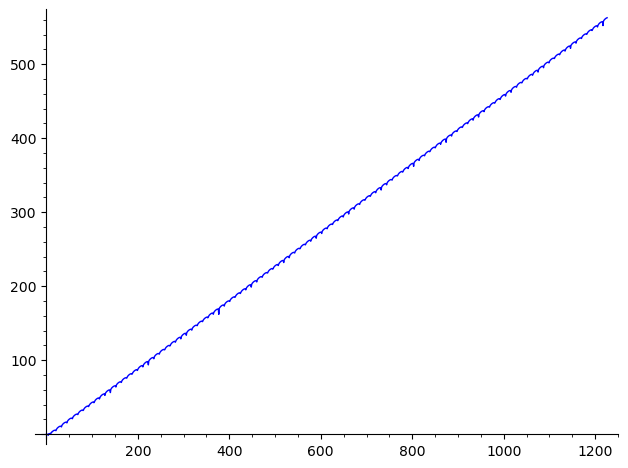

In [10]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

level = 11
bound =1225
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
now=(time.time()-start)/60
print("curve expansion finished at minutes ",now)
print("label:", label)
coeffs_list=[pair[1] for pair in expansion]
now=(time.time()-start)/60
print("coeffs_list finished at minutes ",now)
h_list=[1]+coeffs_list
now=(time.time()-start)/60
print("h_list finished at minutes ",now)
j_list=j_sequence_from_h(h_list)
now=(time.time()-start)/60
print("j_list finished at minutes ",now)
c=1 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
deformed_j_list=[c]+j_list
now=(time.time()-start)/60
print("deformed_j_list finished at minutes ",now)
deformed_h_list=h_sequence_from_j(deformed_j_list)
now=(time.time()-start)/60
print("deformed_h_list finished at minutes ",now)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(201):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

countzeros=0
countnegatives=0
for x in deformed_h_list:
    if x==0:
        countzeros+=1
    if x<0:countnegatives+=1
print("anomalies:",countzeros,countnegatives)   


logplot=[]
for x in deformed_h_list:
    if x==0:
        logplot.append(x)
    if x>0:
        logplot.append(RR(log(x)))
    if x<0:
        logplot.append(RR(log(-x)))

        
p = list_plot(logplot, plotjoined=True, axes_labels=['', ''])
print("LOGPLOT")
p.show()

chi_list_a=chi_list[:300]
chi_list_b=chi_list[301:400]
chi_list_c=chi_list[401:450]
chi_list_d=chi_list[450:480]
chi_list_e=chi_list[481:500]

with open('/Users/barrybrent/data2/run17may26no13.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run17may26no14.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run17may26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run17may26no16.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run17may26no16a.txt', 'wb') as wfile:
    pickle.dump(chi_list_a, wfile)
with open('/Users/barrybrent/data2/run17may26no16b.txt', 'wb') as wfile:
    pickle.dump(chi_list_b, wfile)
with open('/Users/barrybrent/data2/run17may26no16c.txt', 'wb') as wfile:
    pickle.dump(chi_list_c, wfile)
with open('/Users/barrybrent/data2/run17may26no16d.txt', 'wb') as wfile:
    pickle.dump(chi_list_d, wfile)
with open('/Users/barrybrent/data2/run17may26no16e.txt', 'wb') as wfile:
    pickle.dump(chi_list_e, wfile)